In [ ]:
# enable logging widget
%load_ext pymor.tools.jupyter

In [ ]:
%%html
<style>
.rise-enabled .jp-RenderedHTMLCommon table {
         font-size: 150%;
}

.rise-enabled .jp-RenderedHTMLCommon p {
    font-size: 1.5rem;
}

.rise-enabled .jp-RenderedHTMLCommon li {
    font-size: 1.5rem;
}


.rise-enabled .jp-RenderedHTMLCommon h2 {
    font-size: 2.9rem;
    font-weight: bold;
}

.rise-enabled .jp-RenderedHTMLCommon h3 {
    font-size: 2.0rem;
    font-weight: bold;
}

.rise-enabled .jupyter-widget-Collapse-header {
    font-size: 1rem;
}

.rise-enabled .jupyter-widget-Collapse-header i{
    font-size: 1rem;
}

.rise-enabled .cm-editor {
    font-size: 1.25rem;
}
</style>

# Structure-preserving MOR for Hamiltonian and port-Hamiltonian Systems in pyMOR

# Outline

<h2>
1. Why preserve structure?<br/>
2. Hamiltonian systems and (very basic) symplectic geometry<br/>
3. Symplectic MOR in pyMOR for Hamiltonian systems <br/>
4. Port-Hamiltonian systems<br/>
5. Structure-preserving MOR for pH systems in pyMOR<br/>
6. Outlook<br/>
</h2>

## What you already know

From the previous lectures: Compute a basiv $V$, do a Galerkin / Petrov-Galerkin projection, get a ROM. We choose the reduced space to make $\lVert u - u_N\rVert$ or $\lVert H - \hat{H}\rVert$ small.

Today we add another requirement: The ROM should be a model **of the same kind** as the FOM. The is what we refer to as **structure preserving MOR**.

# 1. Why preserve structure?

Many models carry a *geometric* statement about energy that is independent of the
discretization:

| | closed system | open system |
|---|---|---|
| model class | Hamiltonian | port-Hamiltonian |
| energy | $\frac{\operatorname{d}}{\operatorname{d}\!t}\mathcal{H}(x(t)) = 0$ | $\frac{\operatorname{d}}{\operatorname{d}\!t}\mathcal{H}(x(t)) \le y^{\top} u$ |
| geometry | symplectic form $J_{2n}$ | Dirac structure |
| consequence | conservation of energy | passivity, stability |

## Another form of structure preservation you might have encountered before

Before touching MOR, let us recall structure preservation for *time integration*. Consider an harmonic oszilator, given by the second order ODE 

$$
m \ddot q(t) - k q(t) = 0
$$  

For simplicity, set $k=m=1$ and rewrite it as a linear ODE system of order one. We will later see that this is actually an instance of a (linear) Hamiltonian system.

$$
\dot{x}(t) = \begin{bmatrix} 0 & 1 \\ -1 & 0\end{bmatrix} x(t),
\qquad
\mathcal{H}(x(t)) := \tfrac{1}{2}\left(q(t)^2 + p(t)^2\right), \qquad x(t) = \begin{bmatrix} q(t) \\ p(t)\end{bmatrix}.
$$

The exact solution moves on circles in the phase space. What do our time steppers do?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[0., 1.], [-1., 0.]])
dt, nt = 0.1, 400
x0 = np.array([1., 0.])

def integrate(step):
    X = np.empty((2, nt + 1))
    X[:, 0] = x0
    for i in range(nt):
        X[:, i + 1] = step @ X[:, i]
    return X

I = np.eye(2)
steps = {
    'explicit Euler': I + dt * A,
    'implicit Euler': np.linalg.solve(I - dt * A, I),
    'implicit midpoint': np.linalg.solve(I - dt / 2 * A, I + dt / 2 * A),
}
trajectories = {name: integrate(step) for name, step in steps.items()}

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for name, X in trajectories.items():
    axs[0].plot(X[0], X[1], label=name)
    axs[1].semilogy(np.arange(nt + 1) * dt, 0.5 * np.sum(X**2, axis=0), label=name)
axs[0].set(xlabel='q', ylabel='p', title='phase space', aspect='equal')
axs[1].set(xlabel='t', ylabel=r'$\mathcal{H}(x(t))$', title='Hamiltonian')
_ = axs[1].legend()

- explicit Euler: spirals **out** (energy blows up),
- implicit Euler: spirals **in** (artificial damping),
- implicit midpoint: stays on the circle: it is a **symplectic** integrator and
  conserves quadratic invariants *exactly*.

# 2. Hamiltonian systems and (very basic) symplectic geometry

## Canonical Hamiltonian systems

Let $\mathcal{H} \colon \mathbb{R}^{2N} \to \mathbb{R}$ be a smooth *Hamiltonian* (the energy).
A **canonical Hamiltonian system** is

$$
\dot{x}(t) = J_{2N} \nabla_x \mathcal{H}(x(t)), \qquad x(0) = x_0,
$$

with the **canonical Poisson matrix**

$$
J_{2N} :=
\begin{bmatrix}
0 & I_N \\
-I_N & 0
\end{bmatrix}
\in \mathbb{R}^{2N \times 2N},
\qquad
J_{2N}^{\top} = -J_{2N},
$$

In pyMOR, the canonical Poisson matrix can be found as a `BlockOperator` in `pymor.operators.symplectic` under the name `CanonicalSymplecticFormOperator`. 

Writing $x = \begin{bmatrix} q \\ p \end{bmatrix}$, this is the familiar
$\dot{q} = \partial_p \mathcal{H}$, $\dot{p} = -\partial_q \mathcal{H}$.

### Property: energy conservation

Along the solution, the Hamiltonian is constant, i.e., 

$$
\frac{\operatorname{d}}{\operatorname{d}\!t} \mathcal{H}(x(t))
= \nabla \mathcal{H}(x(t))^{\top} \dot{x}(t)
= \underbrace{\nabla \mathcal{H}(x(t))^{\top} J_{2N} \nabla \mathcal{H}(x(t))}_{= 0 \text{ since } J_{2N}^{\top} = -J_{2N}}
= 0 .
$$

The last equality hold true since $J_{2N}$ is skew-symmetric: 

$$
y^\top J_{2N} y = y^\top J_{2N}^\top y = y^\top (- J_{2N}) y = - y^\top J_{2N} y.
$$

## Quadratic Hamiltonians

For todays lecture, we restrict ourselves to the **linear** ODEs, i.e., a quadratic Hamiltonian

$$
\mathcal{H}(x) = \tfrac{1}{2} x^{\top} H x + x^{\top} h,
\qquad H = H^{\top} \in \mathbb{R}^{2N \times 2N},
\quad h \in \mathbb{R}^{2N},
$$

which yields the linear system

$$
\dot{x}(t) = J_{2N} \left( H x(t) + h \right).
$$

This is exactly what a 
`QuadraticHamiltonianModel` (find it in `pymor.models.symplectic`) gives us

```
∂_t u(t, μ) = J * H_op(t, μ) * u(t, μ) + J * h(t, μ)
```

Note that $H$ (`H_op`) is the operator of the *energy*, not the system matrix.
The system matrix is $J_{2N} H$.

## Example: linear wave equation

As our guiding example, we consider a linear wave equation in one spatial dimension. This is a PDE. After semi-discretization in space, this will result in an ODE system, that can be written as a (high-dimensional) Hamiltonian system. 

$$
\partial_{tt} u(t,\xi) = c^2\, \partial_{\xi\xi} u(t,\xi),
\qquad \xi \in (0, \ell), \quad u(t, 0) = u(t, \ell) = 0 .
$$

We will later choose an inital displacement and an initial velocity to make the solution unique. 

In order to obtain the (canonical) Hamiltonian form, introduce $q := u$, $p := \partial_t u$ and discretize the spatial domain via finite differences
($D_{\xi\xi} \approx \partial_{\xi\xi}$, $\Delta \xi = \ell/(N-1)$):

$$
\frac{\operatorname{d}}{\operatorname{d}\!t}
\begin{bmatrix} q \\ p \end{bmatrix}
=
\begin{bmatrix} 0 & I_N \\ -I_N & 0 \end{bmatrix}
\underbrace{
\begin{bmatrix} -c^2 D_{\xi\xi} & 0 \\ 0 & I_N \end{bmatrix}}_{=: H}
\begin{bmatrix} q \\ p \end{bmatrix},
\qquad
\mathcal{H}(x) = \tfrac{1}{2}\left(
\underbrace{- c^2 q^{\top} D_{\xi\xi} q}_{\text{potential}}
+ \underbrace{p^{\top} p}_{\text{kinetic}} \right).
$$

## Symplectic matrices & the symplectic inverse

> ### Definition
>
> A matrix $V \in \mathbb{R}^{2N \times 2k}$ is called ***symplectic*** if
>
> $$ V^{\top} J_{2N} V = J_{2k} . $$

## Definition

> For a symplectic matrix $V \in \mathbb{R}^{2N \times 2k}$, we define the **symplectic inverse**
>
> $$
V^{+} := J_{2k}^{\top} V^{\top} J_{2N} \in \mathbb{R}^{2k \times 2N} .
$$

Careful: The $+$ in the superscript does not denote a Moore-Penrose inverse here! The symplectic inverse is in general a different object. 

The symplectic inverse is a left inverse:

$$
V^{+} V = J_{2k}^{\top} \underbrace{V^{\top} J_{2N} V}_{= J_{2k}} = J_{2k}^{\top} J_{2k} = I_{2k}.
$$

This implies that $V V^{+}$ is a projection onto $\operatorname{range}(V)$ - in general an **oblique** one.

An important identity that makes the whole structure preservation true:

$$
V^{+} J_{2N}
= J_{2k}^{\top} V^{\top} \underbrace{J_{2N} J_{2N}}_{= -I}
= - J_{2k}^{\top} V^{\top}
= J_{2k} V^{\top} .
$$

## Symplectic Galerkin projection

Ansatz $x \approx V x_r$ with $V$ symplectic, insert and test with $V^{+}$:

$$
\begin{align*}
V \dot{x}_r &= J_{2N}\left( H V x_r + h\right) \\
\Longrightarrow \quad
\dot{x}_r &= V^{+} J_{2N} \left( H V x_r + h \right) \\
 &= J_{2k} V^\top \left(H V x_r + h \right) \\
&= J_{2k} \left( \underbrace{V^{\top} H V}_{=: H_r} x_r + \underbrace{V^{\top} h}_{=: h_r} \right) \\
&= J_{2k} \nabla_{x_r} \mathcal{H}_r(x_r)
\end{align*}
$$

 with reduced (quadratic) Hamiltonian $$\begin{align*}
 \mathcal{H}_r(x_r) = \tfrac{1}{2} x_r^{\top} V^{\top} H V x_r + x_r^{\top} V^{\top} h = \mathcal{H}(V x_r). 
 \end{align*}$$
 Thus, the ROM is **again a canonical Hamiltonian system**, where the reduced Hamiltonian is the FOM Hamiltonian restricted to the reduced space.

## What goes wrong without it

Plain Galerkin with an orthonormal (POD) basis gives

$$
\dot{x}_r = \underbrace{V^{\top} J_{2N} H V}_{\text{no structure}} x_r ,
$$

Thus

- The reduced system matrix is not of the form $J_{2k} H_r$ with $H_r$ symmetric,
- so no quantity is conserved,
- and its eigenvalues can leave the imaginary axis $\Rightarrow$ exponential growth.

We will see all of this happen in a minute.

## Orthosymplectic bases

A basis that is **both** symplectic and orthonormal
is called *orthosymplectic*. Then

$$
V^{+} = V^{\top},
$$

so the symplectic Galerkin projection *is* the orthogonal projection, and we keep the good
conditioning of an orthonormal basis.

One can show that orthosymplectic bases have the block form

$$
V = \begin{bmatrix} E & F \end{bmatrix}
= \begin{bmatrix} \Phi & -\Psi \\ \Psi & \Phi \end{bmatrix},
\qquad E, F \in \mathbb{R}^{2N \times k},
$$

i.e. $F = J_{2N}^{\top} E$: the second half of the basis is determined by the
first half. In pyMOR, a symplectic basis is represented by its two
components \(E\) and \(F\). We will see how this work exactly soon.  

## Proper symplectic decomposition (PSD)

We estabilshed that in order to preserve the Hamiltonian structure, we require a symplectic matrix $V$ in the ansatz space and its symplectic inverse in the test space. 
Thus far, we did not discuss how to obtain such a matrix from a given set of snapshots. 

Proper symplectic decomposition (PSD) is the symplectic analogue of POD. Given snapshots $X = [x(t_1; \mu_1), \dots, x(t_n; \mu_1), \dots x(t_{n_s}; \mu_l)]$, solve

$$
\min_{V \in \mathbb{R}^{2N \times 2k}} \left\lVert X - V V^{+} X \right\rVert_{\operatorname{F}}
\qquad \text{s.t.} \quad V^{\top} J_{2N} V = J_{2k} .
$$

Unlike POD, this problem has **no known closed-form solution**. The available algorithms solve restrictions of it (and are available in pymOR, in `pymor.algorithms.symplectic`):

| method | basis | idea |
|---|---|---|
| `psd_cotangent_lift` | orthosymplectic | POD of $[X_q, X_p] \in \mathbb{R}^{N \times 2 n_s}$, then $V = \operatorname{diag}(\Phi, \Phi)$ |
| `psd_complex_svd` | orthosymplectic | POD of $X_q + \mathrm{i} X_p \in \mathbb{C}^{N \times n_s}$, then $V = [\operatorname{Re}\Psi, -\operatorname{Im}\Psi; \operatorname{Im}\Psi, \operatorname{Re}\Psi]$ |
| `psd_svd_like_decomp` | symplectic, *not* orthonormal | SVD-like decomposition $X = S D Q^{\top}$ with some special structure pick columns of $S$ |

`psd_cotangent_lift` and `psd_complex_svd` where introduced in
[[Peng/Mohseni '16]](https://doi.org/10.1137/140978922),
the `psd_svd_like_decomp` in
[[Buchfink/Bhatt/Haasdonk '19]](https://doi.org/10.3390/mca24020043). The is also a `symplectic_gram_schmidt` algorithm available in pyMOR, that is leave out here for simplicitiy. 

# 3. Symplectic MOR in pyMOR

## The building blocks - a summary

| pyMOR object | module | role |
|---|---|---|
| `QuadraticHamiltonianModel` | `pymor.models.symplectic` | the FOM: $\dot{x} = J (H_{op} x + h)$ |
| `CanonicalSymplecticFormOperator` | `pymor.operators.symplectic` | $J_{2N}$ as a `BlockOperator` |
| `SymplecticBasis` | `pymor.algorithms.symplectic` | the basis $V = [E, F]$ |
| `psd_cotangent_lift`, `psd_complex_svd`, `psd_svd_like_decomp` | `pymor.algorithms.symplectic` | basis generation |
| `QuadraticHamiltonianRBReductor` | `pymor.reductors.symplectic` | symplectic Galerkin projection |
| `ImplicitMidpointTimeStepper` | `pymor.algorithms.timestepping` | the symplectic integrator |

## `SymplecticBasis`

A `SymplecticBasis` is **not** a `VectorArray`. It stores *pairs* of basis vectors

$$
E = (e_i)_{i=1}^{k}, \qquad F = (f_i)_{i=1}^{k},
\qquad V = \begin{bmatrix} E & F \end{bmatrix} \in \mathbb{R}^{2N \times 2k},
$$

as two `VectorArrays`. The relation between those two vectory arrays is what makes the basis symplectic.
Noteworthy: `len(basis)` is $k$, not $2k$. 

Useful methods:

- `to_array()` $\rightarrow$ the `VectorArray` $[E, F]$,
- `from_array(U)` $\rightarrow$ split a `VectorArray` of even length into $E$ and $F$ and returns a `SymplecticBasis` constructed from these. 
- `transposed_symplectic_inverse()` $\rightarrow$ $(V^{+})^{\top}$ as a `SymplecticBasis`,
- like other bases, a `SymplecticBasis` can be extended with its `extend` method. Different variant (`svd_like`, `complex_svd` and `symplectic_gram_schmidt`) exists as options about how symplecticity is handled. 

The constructor **checks symplecticity** (the default, can be turned off) and raises an error if it is violated. 

**In practice**: All of PSD methods return a `SymplecticBasis`, so typically, you do not have to touch the `SymplecticBasis` constructor yourself. 

## The FOM: linear wave equation

We follow pyMOR's `symplectic_wave_equation.py` demo
(experiment from [[Peng/Mohseni '16]](https://doi.org/10.1137/140978922)).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

from pymor.algorithms.pod import pod
from pymor.algorithms.symplectic import psd_cotangent_lift, psd_complex_svd, psd_svd_like_decomp
from pymor.algorithms.to_matrix import to_matrix
from pymor.models.symplectic import QuadraticHamiltonianModel
from pymor.operators.block import BlockDiagonalOperator
from pymor.operators.numpy import NumpyMatrixOperator
from pymor.reductors.basic import InstationaryRBReductor
from pymor.reductors.symplectic import QuadraticHamiltonianRBReductor
from pymor.vectorarrays.numpy import NumpyVectorSpace
from pymor.operators.constructions import IdentityOperator

# the BlockOperator warns about missing solver_options
from pymor.core.logger import set_log_levels
set_log_levels({'pymor.operators.block.BlockOperator': 'ERROR'})

Lets discretize the linear wave equation and set up a quadratic Hamiltonian system. 

In [2]:
def discretize_wave(T=10., n_x=500, wave_speed=0.1):
   nt = int(T / 0.01)
   ell = 1.
   dx = ell / (n_x - 1)
   space = NumpyVectorSpace(n_x)

   # H_op = diag(-c^2 * D_xx, I)
   Dxx = diags([-2 * np.ones(n_x), np.ones(n_x - 1), np.ones(n_x - 1)], [0, 1, -1], format='csr')

   H_op = BlockDiagonalOperator([
      NumpyMatrixOperator(-(wave_speed / dx)**2 * Dxx),
      IdentityOperator(space),
   ])

   # initial data: a smooth bump, zero velocity
   h = lambda s: ((0 <= s) * (s <= 1) * (1 - 3 / 2 * s**2 + 3 / 4 * s**3) + (1 < s) * (s <= 2) * ((2 - s)**3) / 4)
   bump = lambda xi: h(np.abs(4 * (xi - ell / 2)))
   
   initial_data = H_op.source.make_array([space.make_array(bump(np.linspace(0, ell, n_x))), space.make_array(np.zeros(n_x))])

   return QuadraticHamiltonianModel(T, initial_data, H_op, nt=nt, name='wave_equation')

In [ ]:
fom = discretize_wave(T=10.)
print(fom)

The solution space (i.e. the phase space) is a `BlockVectorSpace` with **two identical subspaces** for $q$ and $p$.  All basis generation algorithms rely on
  this splitting. If `H_op` is not provided as a `BlockOperator` already, `QuadraticHamiltonianModel` casts it into this form
  automatically. The same holds for the initial data. 

 If you pass `nt` (as we did) instead of a `time_stepper`, you get the `ImplicitMidpointTimeStepper` — the symplectic integrator is the default.

In [ ]:
print(fom.time_stepper)
print(fom.J)

### Solving the FOM

We solve the FOM and visualize the solution to check if we set up everything correctly. 

In [ ]:
U = fom.solve()
U.dim, len(U) 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(U.blocks[0].to_numpy(), aspect='auto', origin='lower', extent=[0, fom.T, 0, 1], cmap='RdBu_r')
ax.set(xlabel='t', ylabel=r'$\xi$', title='displacement $q(t, \\xi)$')
_ = fig.colorbar(im, ax=ax)

In [ ]:
# Vertical slices of the space-time heatmap: string shape at fixed times.
q_snapshots = U.blocks[0].to_numpy()  # rows: spatial points, columns: times
xi = np.linspace(0, 1, q_snapshots.shape[0])
snapshot_times = np.linspace(0, fom.T, q_snapshots.shape[1])

fig, axs = plt.subplots(1, 5, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, target_time in zip(axs, [0, 2.5, fom.T / 2, 7.5, fom.T]):
    index = np.argmin(np.abs(snapshot_times - target_time))
    ax.plot(xi, q_snapshots[:, index], linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set(xlabel=r'space $\xi$', title=f't = {snapshot_times[index]:g}', xlim=(0, 1))
    ax.grid(alpha=0.25)

amplitude = np.max(np.abs(q_snapshots))
axs[0].set(ylabel=r'displacement $q(t, \xi)$',
           ylim=(-1.1 * amplitude, 1.1 * amplitude))
fig.suptitle('String shape at five fixed times')
fig.tight_layout()


### The Hamiltonian

`eval_hamiltonian` evaluates $\mathcal{H}(u) = \tfrac12 u^{\top} H_{op} u + u^{\top} h$
along a trajectory:

In [ ]:
ham_fom = fom.eval_hamiltonian(U)
print(f'relative drift over [0, T]: {np.abs(ham_fom - ham_fom[0]).max() / ham_fom[0]:.2e}')

## Building symplectic bases

All algorithms to construct symplectic bases can be found in `pymor.algorithms.symplectic`. 

In [ ]:
RB_CL = psd_cotangent_lift(U, modes=20)   # 20 = reduced dimension 2k, so k = 10
print(f'{type(RB_CL).__name__} with len(RB_CL) = {len(RB_CL)}')
print(f'E and F hold {len(RB_CL.E)} vectors each, in {RB_CL.phase_space}')
print(f'V = [E, F] is a VectorArray of length {len(RB_CL.to_array())}')

### Checking symplecticity and orthosymplecticity

In [ ]:
tsi = RB_CL.transposed_symplectic_inverse()
sympl_err = np.abs(tsi.to_array().inner(RB_CL.to_array()) - np.eye(2 * len(RB_CL))).max()
orth_err = np.abs(RB_CL.to_array().gramian() - np.eye(2 * len(RB_CL))).max()
print(f'|V^+ V - I|   = {sympl_err:.2e}')
print(f'|V^T V - I|   = {orth_err:.2e}   (orthosymplectic!)')

In [ ]:
RB_svd_like = psd_svd_like_decomp(U, modes=20)
tsi_sl = RB_svd_like.transposed_symplectic_inverse()
print(f'|V^+ V - I| = {np.abs(tsi_sl.to_array().inner(RB_svd_like.to_array()) - np.eye(20)).max():.2e}')
print(f'|V^T V - I| = {np.abs(RB_svd_like.to_array().gramian() - np.eye(20)).max():.2e}')

The SVD-like basis is symplectic but **not** orthonormal: here $V^{+} \neq V^{\top}$
and the projection $V V^{+}$ is genuinely oblique. It can be more accurate, at the price of a
worse conditioned basis.

## The reductor

The `QuadraticHamiltonianRBReductor` is constructed via a `QuadraticHamiltonianModel` and a `SymplecticBasis`. 

In [ ]:
reductor = QuadraticHamiltonianRBReductor(fom, RB_CL)
rom = reductor.reduce()

Lets look at the reductors `reduce` method to see what actually happens. 

In [ ]:
from pymor.tools.formatsrc import print_source
print_source(reductor.reduce)

Now lets take a look at the ROM and check if it inherited the structure 

In [ ]:
print(rom)

The ROM is a `ReducedQuadraticHamiltonianModel`.

Note that the Block structure in the solution space is lost. This is a design decision currently made in pyMOR - as no specialized solvers exists for general blocked systems at the moment in pymor, and keeping the `BlockStructure` in the ROM would increase the runtime significantly. Thus, it is in currently recommended to have a ROM without a blocked structure. 

In [ ]:
print(rom.time_stepper)
print(rom.solution_space)
print(rom.J)

In [ ]:
u = rom.solve()
U_rom = reductor.reconstruct(u)
rel_err = np.sqrt((U - U_rom).norm2().sum() / U.norm2().sum())
print(f'relative reduction error: {rel_err:.3e}')
print(f'relative drift of the ROM Hamiltonian: '
      f'{np.abs(rom.eval_hamiltonian(u) - rom.eval_hamiltonian(u)[0]).max() / ham_fom[0]:.2e}')

## Reproduction experiment: symplectic vs. POD

We compare all three PSD variants against POD with `InstationaryRBReductor`
(the standard non-structure-preserving choice), for a range of reduced dimensions,
and record

- the **projection error** $\lVert X - V V^{+} X\rVert$ (how good is the *space*),
- the **reduction error** $\lVert X - V x_r \rVert$ (how good is the *ROM*).

In [ ]:
SYMPLECTIC_METHODS = {
    'cotangent_lift': psd_cotangent_lift,
    'complex_svd': psd_complex_svd,
    'svd_like': psd_svd_like_decomp,
}
red_dims = np.array([4, 8, 12, 20, 28, 40])
max_dim = red_dims.max()

bases = {name: gen(U, max_dim) for name, gen in SYMPLECTIC_METHODS.items()}

n_pairs = len(U) // 2
bases['pod'], _ = pod(U, modes=max_dim)

In [ ]:
def run_mor(method, dim):
    if method == 'pod':
        RB = bases['pod'][:dim]
        reductor = InstationaryRBReductor(fom, RB)
        U_proj = RB.lincomb(RB.inner(U))
    else:
        #We have to divide by two, because sclicing in a SymplecticBasis slices both E and F, 
        # so we need to take half the dimension to get the correct number of pairs.
        RB = bases[method][:dim // 2]
        reductor = QuadraticHamiltonianRBReductor(fom, RB)
        U_proj = RB.lincomb(RB.transposed_symplectic_inverse().to_array().inner(U))

    rom = reductor.reduce()
    U_rom = reductor.reconstruct(rom.solve())

    return (np.sqrt((U - U_proj).norm2().sum()), np.sqrt((U - U_rom).norm2().sum()))

norm_U = np.sqrt(U.norm2().sum())
results = {method: np.array([run_mor(method, dim) for dim in red_dims]) / norm_U for method in list(SYMPLECTIC_METHODS) + ['pod']}

In [ ]:
styles = {'pod': ('blue', '^'), 'cotangent_lift': ('red', '.'), 'complex_svd': ('green', 's'), 'svd_like': ('gray', 'X')}

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(11, 4))
for method, res in results.items():
    color, marker = styles[method]
    axs[0].semilogy(red_dims, res[:, 0], color=color, marker=marker)
    axs[1].semilogy(red_dims, res[:, 1], color=color, marker=marker, label=method)
axs[0].set(xlabel='reduced dimension 2k', ylabel='rel. err.', title='projection error')
axs[1].set(xlabel='reduced dimension 2k', title='reduction error')
_ = axs[1].legend()

### Reading the plot

- **Left:** POD has the *best* projection error - of course, it is the optimal
  basis in terms of this measure. The symplectic bases pay for their constraint.
- **Right:** the symplectic reduction errors essentially *coincide with* their projection
  errors, while the POD reduction error stagnates and is worse than every symplectic basis for every reduced dimension. 

## An explantion for the POD error

Let us investigate the spectrum of the reduced system matrix ($\dot{x}_r = A_r x_r$):

In [ ]:
rom_sympl = QuadraticHamiltonianRBReductor(fom, bases['cotangent_lift']).reduce()
rom_pod = InstationaryRBReductor(fom, bases['pod']).reduce()

print("Symplectic ROM is of class", type(rom_sympl).__name__)
print("POD ROM is of class", type(rom_pod).__name__)

# InstationaryModel: u_t + operator(u) = rhs, hence A_r = -operator
ev_sympl = np.linalg.eigvals(-to_matrix(rom_sympl.operator, format='dense'))
#ev_sympl = np.linalg.eigvals(to_matrix(rom_sympl.J @ rom_sympl.H_op), format='dense')
ev_pod = np.linalg.eigvals(-to_matrix(rom_pod.operator, format='dense'))
print(f'symplectic: max |Re(λ)| = {np.abs(ev_sympl.real).max():.2e}')
print(f'POD:        max |Re(λ)|  = {ev_pod.real.max():.2e}')

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ev_pod.real, ev_pod.imag, 'x', color='blue', label='pod')
ax.plot(ev_sympl.real, ev_sympl.imag, '.', color='red', label='cotangent_lift')
ax.axvline(0, color='k', lw=0.5)
ax.set(xlabel=r'$\operatorname{Re}(\lambda)$', ylabel=r'$\operatorname{Im}(\lambda)$',
       title='eigenvalues of the reduced system matrix')
_ = ax.legend()

The symplectic ROM has a purely imaginary spectrum (up to round-off). Explanation for this: 

$H_r$ is symmetric (as a Hessian) and positive definite (as H is p.d. and $V$ has full column-rank). Take an Choleksy factor of $H_r = LL^\top$. Then, the system matrix of the symplectic ROM is similar to a skew-symmetric matrix: 

$$
L^\top \left(J_{2k} H_r\right) L^{-\top} = L^\top J_{2k} LL^\top L^{-\top} = L^\top J_{2k} L =: S 
$$

and $S$ is skew. Thus, due to the similarity transform, $J_{2k} H_r$ has the same eigenvalues as the skew-symmetric matrix $S$, for which it is known that all eigenvalues are purely imaginary. 


The POD ROM has eigenvalues with positive real part. The system matrix of the reduced system is $V^\top J_{2N} H V$, and because $V$ has no special structure if computed via POD, no such argument can be done. 

## Long-time behaviour

We keep the bases trained on $[0, 10]$ and simulate the ROMs on $[0, 50]$:

In [ ]:
fom_long = discretize_wave(T=50.)
U_long = fom_long.solve()
ham_long = fom_long.eval_hamiltonian(U_long)

red_sympl = QuadraticHamiltonianRBReductor(fom_long, bases['cotangent_lift'])
red_pod = InstationaryRBReductor(fom_long, bases['pod'])

U_sympl = red_sympl.reconstruct(red_sympl.reduce().solve())
U_pod = red_pod.reconstruct(red_pod.reduce().solve())

norm_long = np.sqrt(U_long.norm2().sum())
print(f'rel. error symplectic: {np.sqrt((U_long - U_sympl).norm2().sum()) / norm_long:.3e}')
print(f'rel. error POD:        {np.sqrt((U_long - U_pod).norm2().sum()) / norm_long:.3e}')

In [ ]:
t_long = np.linspace(0, fom_long.T, len(U_long))
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_long, ham_long, 'k', label='FOM')
ax.semilogy(t_long, fom_long.eval_hamiltonian(U_sympl), color='red', label='cotangent_lift')
ax.semilogy(t_long, fom_long.eval_hamiltonian(U_pod), color='blue', label='pod')
ax.axvline(10, color='k', ls=':', lw=1)
ax.set(xlabel='t', ylabel=r'$\mathcal{H}$', title='Hamiltonian, basis trained on [0, 10]')
_ = ax.legend()

## Exercise

1. Repeat the experiments with `psd_complex_svd` and `psd_svd_like_decomp`
   instead of `psd_cotangent_lift`. Do all symplectic bases behave the same?
2. Take the symplectic ROM `rom_sympl` and replace its time stepper by
   `ImplicitEulerTimeStepper(1000)` using
   `rom_sympl.with_(time_stepper=...)` (import it from
   `pymor.algorithms.timestepping`). Compute the Hamiltonian of the resulting
   trajectory. What do you observe, and why?

# 4. Port-Hamiltonian systems and basic properties

## From closed to open systems

The Hamiltonian systems introduced are **closed**: energy is conserved, there is no input
and no output. 

Many physical systems exchange energy with their environment through **ports**. Port-Hamiltonian systems describe this exchange explicitly, accounting for energy storage, dissipation, and external power.

They are the natural language for multi-physics and network modelling: interconnecting
pH systems through their ports gives a pH system again. There exists a branch within MOR called **modular MOR**, that deal with MOR of such interconnected systems. This is unfortunately out of scope for todays lecture. 

## pH LTI systems

> ### Definition
>
> An LTI system is ***port-Hamiltonian*** if it can be written as
>
> $$
  \begin{aligned}
    E \dot{x}(t) & = (J - R) Q x(t) + (G - P) u(t), \\
           y(t) & = (G + P)^{\top} Q x(t) + (S - N) u(t),
  \end{aligned}
  $$
>
> with $H := Q^{\top} E$ such that
>
> $$
  H = H^{\top} \succ 0, \qquad
  \Gamma^{\top} = -\Gamma, \qquad
  \mathcal{W} = \mathcal{W}^{\top} \succcurlyeq 0,
  $$
>
> where
>
> $$\Gamma := \begin{bmatrix} J & G \\ -G^{\top} & N \end{bmatrix}, \qquad \mathcal{W} := \begin{bmatrix} R & P \\ P^{\top} & S \end{bmatrix}.$$

### Reading the definition

$$
\Gamma = \begin{bmatrix} J & G \\ -G^{\top} & N \end{bmatrix} \text{ skew}
\qquad\qquad
\mathcal{W} = \begin{bmatrix} R & P \\ P^{\top} & S \end{bmatrix} \succcurlyeq 0
$$

- $\Gamma$ is the **structure matrix**: energy *routing*. $J$ is the internal
  interconnection, $G$ couples state and ports. Skew $\Rightarrow$ lossless.
- $\mathcal{W}$ is the **dissipation matrix**: energy *loss*. $R$ dissipates internally,
  $S$ at the ports. Positive semi-definite $\Rightarrow$ never produces energy.
- $H = Q^{\top} E \succ 0$ defines the energy
  $\mathcal{H}(x) = \tfrac{1}{2} x^{\top} H x$.

In many applications $E = I$ or $Q = I$ (the *Berlin form* has $Q = I$, so $H = E$). Any `PHLTIModel` can be transformed into Berlin form via `to_berlin_form()`. 
pyMOR currently supports pH systems with **nonsingular $E$**. 

In pyMOR, an pH LTI system can be created using the `PHLTIModel` in `pymor.models.iosys`. `PHLTIModel` inherits from `LTIModel`, so **everything from the systems theory lecture still
works**: `transfer_function`, `h2_norm`, `poles`, `bode_plot`, subtraction of models, and
every reductor that expects an `LTIModel`.

What it adds are the operators `J, R, G, P, S, N, E, Q`. Note that in the construction of an `PHLTIModel`, the properties of the matrices are **not** checked. It is the users responsability to plug in correct matrices.

## The power balance and passivity



For simplicity, lets assume $P=0, S=0, N=0$. By the chain rule + plugging in the ODE, we obtain

$$
\begin{align*}
\frac{\operatorname{d}}{\operatorname{d}\!t} \mathcal{H}(x)
&= x^{\top} Q^{\top} E \dot{x}
 = x^{\top} Q^{\top} \left[(J - R) Q x + G u\right] \\
&= \underbrace{(Qx)^{\top} J (Qx)}_{= 0}
   - (Qx)^{\top} R (Qx) + x^{\top} Q^{\top}G u .
\end{align*}
$$

where $ (Qx)^\top J (Qx) = 0$ due to the skew-symmetry of $J$. Rewriting this by introducing the supplied power
$y^{\top} u = x^{\top} Q^{\top} Gu$  yields: 

$$
\boxed{\;
\frac{\operatorname{d}}{\operatorname{d}\!t} \mathcal{H}(x)
= y^{\top} u
- (Qx)^\top R (Qx)
\;\le\; y^{\top} u \; }
$$

Here, the first equality is usually called **power balance**, whereas the inequality is refered to as the **passivity inequality** (which holds as $\mathcal{W}$ is pd.). Power balance has a nice interpretation: The change of the stored energy is the external supplied power $y^\top u$ minus the dissipated power. Often, passivity is defined equivalently as: 


> ### Definition (passivity)
> The system is ***passive*** if there is a storage function $\mathcal{H} \ge 0$ with
> $$\mathcal{H}(x(t_1)) - \mathcal{H}(x(t_0)) \le \int_{t_0}^{t_1} y(\tau)^{\top} u(\tau) \operatorname{d}\!\tau .$$



Another important property (that some reductors will aim to preserve in the ROM) is positive realness. 


> ### Definition (positive realness)
> The system with transfer function $\mathcal{T}$ is called ***positive real***, if 
> - $\mathcal{T}$ has no poles in $s \in \mathbb{C}, \mathrm{Re}(s) > 0$, and satisfies
> - $\mathcal{T}(s) + \mathcal{T}(s)^{\operatorname{H}} \succcurlyeq 0$ for all $s \in \mathbb{C}, \mathrm{Re}(s) > 0$.

> ### Theorem 
>For linear pH systems (with regular $E$) it holds: 
> - linear port-Hamiltonian $\Longrightarrow$ passive $\Longrightarrow$ positive real 
> 
> The converses do not hold in general. 

> ### Theorem
> For a **minimal** and **stable** LTI system the following are equivalent:
> 1. the system is passive,
> 2. the system is port-Hamiltonian,
> 3. the system is positive real.
>
>
> See [[Breiten/Unger '22]](https://doi.org/10.1016/j.automatica.2022.110368).

Minimality is important for the converse direction, because positive realness is a property of the transfer function - thus is only sees the input-output behaviour. It cant detect uncontrollable or unobservable internal dynamics. Minimality means that the realization is both controlable and observeable, thus no hidden dynamics can occur. 

## The KYP inequality

Lets fix $E = I$. The bridge from **passive** to **port-Hamiltonian** is the
**Kalman-Yakubovich-Popov (KYP) LMI**. How this works: Lets assume a storage function of some LTI system 

$$
\mathcal{H}(x(t)) = \frac{1}{2} x^\top X x.
$$

with $X = X^\top \succ 0$. Differentiating and plugging in the ODE yields 

$$
\begin{aligned}
\frac{d}{dt}\mathcal{H}(x(t)) &= \frac{1}{2} \left( A^\top X + X A \right) + x^\top XBu \\
y^\top u &= x^\top C^\top u + \frac{1}{2} x^\top (D + D^\top) x
\end{aligned}
$$

Subtracting these two (due to passitivity we know this quantity is positive) 

$$
y^\top u - \frac{d}{dt}\mathcal{H}(x(t)) = \frac{1}{2} \begin{bmatrix} x^\top & u^\top \end{bmatrix} \begin{bmatrix}  - A^\top X - XA & C^\top - XB \\ C - B^\top X & D + D^\top \end{bmatrix} \begin{bmatrix} x \\ u \end{bmatrix} \geq 0
$$

Thus, finding such a storage function is equivalent to finding a solution  $X = X^\top \succ 0$ of 

$$
\begin{bmatrix}
-A^{\top} X - X A & C^{\top} - X B \\
C - B^{\top} X & D + D^{\top}
\end{bmatrix}
\succcurlyeq 0 .
$$

If this is satisfied, then $X$ defines the (quadratic) energy of a system via $\mathcal{H} = \frac{1}{2} x^\top X x$, which satisfies the passivity condition. Any solution $X$ yields a pH realization with $Q = X$:

$$
J = \tfrac12\left(A X^{-1} - X^{-1}A^{\top}\right), \quad
R = -\tfrac12\left(A X^{-1} + X^{-1}A^{\top}\right), \quad
G = \tfrac12\left(X^{-1}C^{\top} + B\right), \quad \dots
$$

This is what `PHLTIModel.from_passive_LTIModel` does. 

In practice, solving the LMI can be replaced by solving a 
positive-real Riccati equation (this is a Schur complement property)

$$
A^{\top} X E + E^{\top} X A
+ (C^{\top} - E^{\top} X B)(D + D^{\top})^{-1}(C - B^{\top} X E) = 0,
$$

which requires $D + D^{\top}$ to be **nonsingular**. Remember this, as it will become an relevant later. 

## Strategy for structure-preserving MOR

Two routes to a pH ROM:

1. **Project in the pH format.** Choose the test space so that the projected matrices
   still satisfy the three pH conditions. $\rightarrow$ `PHLTIPGReductor`, `PHIRKAReductor`.
2. **Preserve passivity, convert afterwards.** Use a reductor that maps passive systems to
   passive systems, then apply `from_passive_LTIModel`.
   $\rightarrow$ `PRBTReductor`, `SpectralFactorReductor`.

## Route 1: the choice $W = QV$

Petrov-Galerkin with trial basis $V$ and test basis $W = QV$ ([[Wolf/Lohmann/Eid/Kotyczka '10]](https://doi.org/10.3166/ejc.16.401-406)), $x \approx V x_r$:

$$ 
\begin{align*}
V^\top Q^\top E V \dot{x}_r &= V^\top Q^\top (J - R) QV x_r + V^\top Q^\top (G - P) u, \\
y_r &= (G + P)^\top QV x_r + (S-N)u
\end{align*}
$$

Define the reduced matrices 

$$ 
\hat{J} := V^\top Q^\top J Q V, \quad \hat{R} := V^\top Q^\top R Q V, \quad \hat{G} := V^\top Q G, \quad \hat{P} := V^\top Q^\top P. 
$$ 

Often, $V$ is chosen to be $Q^\top E$ orthogonal. This then yields the reduced system 

$$
\begin{align*}
\dot{x}_r &= (\hat{J} - \hat{R}) x_r + (\hat{G} - \hat{P}) u, \\
y_r &= (\hat{G} + \hat{P}) x_r + (S - N)u 
\end{align*}
$$

The pH properties remain satisfied, as this **congruence transformation** preserves skewness and positive semi-definiteness. 

Looking at the `project_operators` method of the `PHLITPGReductor`: 

In [ ]:
from pymor.tools.formatsrc import print_source
from pymor.reductors.ph.basic import PHLTIPGReductor

print_source(PHLTIPGReductor.project_operators)

Moreover

$$
\hat{E} = W^{\top} E V = V^{\top} Q^{\top} E V = V^{\top} H V,
\qquad \hat{Q} = I_r
\qquad \Longrightarrow \qquad
\hat{H} = \hat{Q}^{\top} \hat{E} = V^{\top} H V \succ 0 .
$$

### The Hamiltonian

$$
\hat{\mathcal{H}}(x_r) = \tfrac12 x_r^{\top} V^{\top} H V x_r = \mathcal{H}(V x_r)
$$

Exactly as in the symplectic case: the reduced energy is the FOM energy restricted to the
reduced space. The ROM is pH **for any choice of $V$** (as soons as $W = QV$) — accuracy is a separate question,
which is what pH-IRKA, PRBT and spectral factorization are about.

# 5. Structure-preserving pH MOR in pyMOR

## The relevant reductors in pyMOR

| reductor | route | returns | preserves |
|---|---|---|---|
| `PHLTIPGReductor` | 1 | `PHLTIModel` | pH structure, given $V$ |
| `PHIRKAReductor` | 1 | `PHLTIModel` | pH structure + $\mathcal{H}_2$-flavoured interpolation |
| `PRBTReductor` | 2 | `LTIModel` | positive real BT, passivity |
| `SpectralFactorReductor` | 2 | `LTIModel` | passivity (if inner ROM is stable) |

All of them are described in detail in
[[Breiten/Unger '22]](https://doi.org/10.1016/j.automatica.2022.110368). It is important to note that for the `PHLTIPGReductor`, the `VectorArray` $V$ (the reduced basis matrix), needs to be computed a priori, whereas all of the other reductors only require the FOM - and construct a suitable $V$ when `reduce` is called. 

We now have all the theoretical ingredients at hand to start with some actual MOR in pyMOR. Lets first import the relevant Reductors, examples, etc. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pymor.algorithms.krylov import tangential_rational_krylov
from pymor.algorithms.timestepping import ImplicitMidpointTimeStepper
from pymor.algorithms.to_matrix import to_matrix
from pymor.models.examples import msd_example
from pymor.models.iosys import PHLTIModel
from pymor.reductors.basic import LTIPGReductor
from pymor.reductors.bt import PRBTReductor, BTReductor
from pymor.reductors.h2 import IRKAReductor
from pymor.reductors.ph.basic import PHLTIPGReductor
from pymor.reductors.ph.ph_irka import PHIRKAReductor
from pymor.reductors.spectral_factor import SpectralFactorReductor
from pymor.operators.constructions import InverseOperator, IdentityOperator

## The toy problem: mass-spring-damper chain

A chain of masses $m_i$ connected by springs $k_i$ and dampers $c_i$
([[Gugercin/Polyuga/Beattie/van der Schaft '12]](https://doi.org/10.1016/j.automatica.2012.05.052)).

- inputs $u_1, u_2$: external forces on the first two masses,
- outputs $y_1, y_2$: velocities of the first two masses,
- state: positions and momenta
- damping enters only through $R$.

In [3]:
fom = msd_example(50, 2) #2 is the number of input (and outputs), so the amount of masses on which a force acts. 
print(fom)

PHLTIModel
    class: PHLTIModel
    number of equations: 50
    number of inputs:    2
    number of outputs:   2
    continuous-time
    port-Hamiltonian
    linear time-invariant
    solution_space:  NumpyVectorSpace(50)


### Verifying the structure

Let us verify if the matrices satisfy the pH properties.

In [4]:
def ph_properties(model):
    densify = lambda op: to_matrix(op, format='dense')
    J, R, G, P, S, N, E, Q = map(densify, (model.J, model.R, model.G, model.P, model.S, model.N, model.E, model.Q))
    H = Q.T @ E
    Gamma = np.block([[J, G], [-G.T, N]])
    W = np.block([[R, P], [P.T, S]])
    
    print("|H - H^T|:        ", np.abs(H - H.T).max())
    print("min eig H:        ", np.linalg.eigvalsh((H + H.T) / 2).min())
    print("|Gamma + Gamma^T|:", np.abs(Gamma + Gamma.T).max())
    print("min eig W:        ", np.linalg.eigvalsh((W + W.T) / 2).min())

ph_properties(fom)

|H - H^T|:         0.0
min eig H:         0.015173370103646899
|Gamma + Gamma^T|: 0.0
min eig W:         0.0


$H=H^\top$, $H \succ 0$, $\Gamma$ skew, $\mathcal{W} \succcurlyeq 0$, here the smallest eigenvalue is exactly $0$
because this model has $S = 0$, $P = 0$.

## The power balance in the time domain

`PHLTIModel` has no final `T` and no time stepper by default; we add them and start from a
nonzero state:

In [5]:
T = 30
nt = 3000
t = np.linspace(0, T, nt + 1)
u = '[sin(t[0]), 0]'

x0 = fom.solution_space.ones()
fom_t = fom.with_(T=T, time_stepper=ImplicitMidpointTimeStepper(nt), initial_data=x0)

X = fom_t.solve(input=u)

#The X required to compute the output is cached, so calling fom.output is cheap
Y = fom_t.output(input=u) 

print(f'{len(X)} state vectors of dimension {X.dim}, output of shape {Y.shape}')

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

3001 state vectors of dimension 50, output of shape (2, 3001)


Let us verify if the dissipation inequality holds.

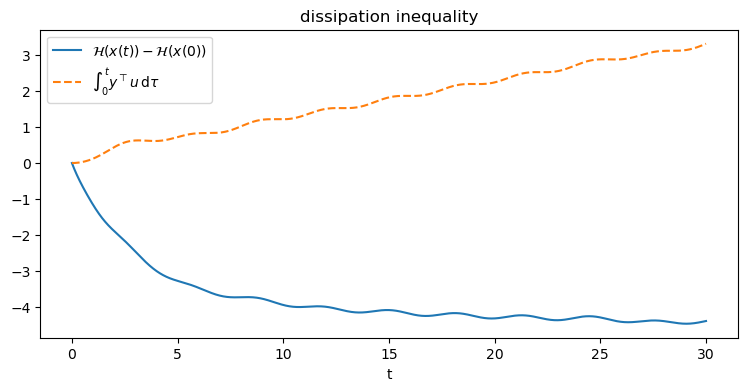

In [6]:
H_mat = to_matrix(fom.Q, format='dense').T @ to_matrix(fom.E, format='dense')

def hamiltonian(X):
    x = X.to_numpy()
    return 0.5 * np.einsum('in,ij,jn->n', x, H_mat, x)

U_in = np.vstack([np.sin(t), np.zeros_like(t)])
power = np.sum(Y * U_in, axis=0)
supplied = np.concatenate([[0.], np.cumsum((power[1:] + power[:-1]) / 2) * (T / nt)])
ham = hamiltonian(X)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, ham - ham[0], label=r'$\mathcal{H}(x(t)) - \mathcal{H}(x(0))$')
ax.plot(t, supplied, '--', label=r'$\int_0^t y^{\top} u \,\mathrm{d}\tau$')
ax.set(xlabel='t', title='dissipation inequality')
_ = ax.legend()

The gap between the two curves is the energy dissipated in $\mathcal{W}$.
This is the property we want the ROM to inherit.

## $W = V$ versus $W = QV$

To isolate the effect of the *projection*, we use **one and the same trial basis** $V$ is computed by
a **tangential rational Krylov basis** (this is essentially what happens internally in IRKA in every iteration).

In [7]:
sigma = np.logspace(-1, 2, 10)
b = fom.B.source.from_numpy(np.ones((len(sigma), fom.dim_input)).T)
V = tangential_rational_krylov(fom.A, fom.E, fom.B, b, sigma)
print(f'trial basis V: {len(V)} vectors of dimension {V.dim}')

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

trial basis V: 10 vectors of dimension 50


Using the `PHLTIReductor` preserves the pH strucure, unlike an `LTIPGReductor`. Note that the basis computed above is not $Q^\top E$ orthogonal. 

In [8]:
reductor_ph = PHLTIPGReductor(fom_t, V) #This uses W = QV per default. 
rom_ph = reductor_ph.reduce()

reductor_g = LTIPGReductor(fom_t, V, V)
rom_g = reductor_g.reduce()

print(f'W = QV yields {type(rom_ph).__name__}')
print(f'W = V  yields {type(rom_g).__name__}')

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

W = QV yields PHLTIModel
W = V  yields LTIModel


### Is the ROM still pH?

In [10]:
ph_properties(rom_ph)

|H - H^T|:         1.3322676295501878e-15
min eig H:         0.01859777963598296
|Gamma + Gamma^T|: 2.220446049250313e-16
min eig W:         -4.054744857350058e-18


The ROM obtained with Galerkin projection is not stable anymore.

In [11]:
print(f'FOM     : max Re(λ) = {fom.poles().real.max():+.3e}')
print(f'W = QV  : max Re(λ) = {rom_ph.poles().real.max():+.3e}')
print(f'W = V   : max Re(λ) = {rom_g.poles().real.max():+.3e}')

FOM     : max Re(λ) = -1.623e-02
W = QV  : max Re(λ) = -9.039e-02
W = V   : max Re(λ) = +4.514e-01


The plain Galerkin ROM has a pole in the right half-plane. Let us simulate both ROMs with
the same input and initial condition as the FOM. 

Before we do that, we have do one more thing: Neither the `PHLTIPGReductor` nor the `LTIPGReductor` project the initial condition for us. We have to take care of that ourselves. 

In [12]:
# Project the initial conditions
# W^\top E (V x0_r_ph - x0) = 0, yields x0_r_ph = (W^\top  E V)^{-1} W^\top E x0
W = fom.Q.apply(V)

x0_r = np.linalg.solve(V.gramian(fom.E), V.inner(x0, product=fom.E))
x0_r_ph = np.linalg.solve(W.inner(V, product=fom.E), W.inner(x0, product=fom.E))

def simulate(rom, reductor):
    rom_t = rom.with_(initial_data=rom.solution_space.from_numpy(x0_r))
    return hamiltonian(reductor.reconstruct(rom_t.solve(input=u)))

def simulate_ph(rom, reductor):
    rom_t = rom.with_(T=T, time_stepper=ImplicitMidpointTimeStepper(nt), initial_data=rom.solution_space.from_numpy(x0_r_ph))
    return hamiltonian(reductor.reconstruct(rom_t.solve(input=u)))

ham_ph = simulate_ph(rom_ph, reductor_ph)
ham_g = simulate(rom_g, reductor_g)

print(f'FOM    : H(0) = {ham[0]:.3f},  H(T) = {ham[-1]:.3e}')
print(f'W = QV : H(0) = {ham_ph[0]:.3f},  H(T) = {ham_ph[-1]:.3e}')
print(f'W = V  : H(0) = {ham_g[0]:.3f},  H(T) = {ham_g[-1]:.3e}')

FOM    : H(0) = 5.125,  H(T) = 7.406e-01
W = QV : H(0) = 0.786,  H(T) = 1.867e-01
W = V  : H(0) = 2.284,  H(T) = 6.718e+09


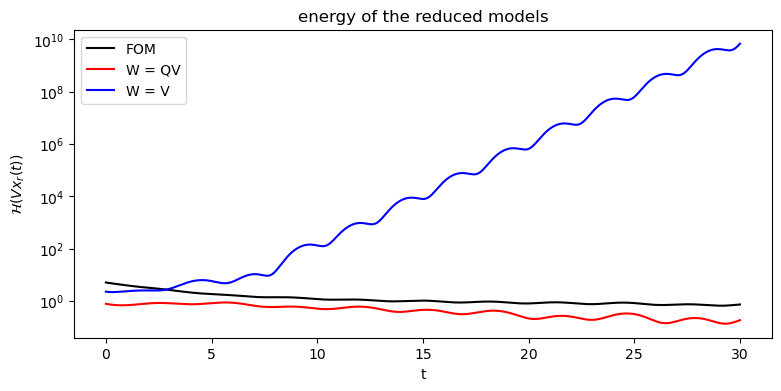

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t, ham, 'k', label='FOM')
ax.semilogy(t, ham_ph, color='red', label='W = QV')
ax.semilogy(t, ham_g, color='blue', label='W = V')
ax.set(xlabel='t', ylabel=r'$\mathcal{H}(V x_r(t))$', title='energy of the reduced models')
_ = ax.legend()

## The specialised reductors

We now compare three reductors that handle the computing of $V$ internally. One of them preserves the pH structure by construction, the other two preserve passivity and thus have to be converted via `_from_passive_LTIModel`. 

`PRBTReductor` and `SpectralFactorReductor` solve a
positive-real Riccati equation, which needs $D + D^{\top}$ nonsingular. The MSD
example has $D = 0$, so we add a regularizing feedthrough term $D + \varepsilon I_m$,
i.e. we perturb $S$:

In [14]:
S = fom.S.matrix.copy()
S += np.eye(S.shape[0]) * 1e-12
fom = fom.with_(S=fom.S.with_(matrix=S))

### pH-IRKA

IRKA, but with $W = QV$ instead of a free test space. The fixed-point iteration therefore
has fewer degrees of freedom, and the ROM comes out as a `PHLTIModel` with $\hat{Q} = I_r$
directly.

In [15]:
rom1 = PHIRKAReductor(fom).reduce(10)
print(f'rom1 is of type {type(rom1).__name__}.')
print("Checking pH properties of rom1:")
ph_properties(rom1)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

rom1 is of type PHLTIModel.
Checking pH properties of rom1:
|H - H^T|:         3.3306690738754696e-16
min eig H:         0.05991232314857209
|Gamma + Gamma^T|: 1.1102230246251565e-16
min eig W:         1e-12


The ROM is a `PHLTIModel` with all the properties satisfied. 

### Positive-real balanced truncation

Balanced truncation with the positive-real Gramians (solutions of a positive-real Riccati
equations) instead of the Lyapunov Gramians. Preserves passivity and returns an `LTIModel`,
which we convert in a post-processing step. The `from_passive_LTIModel` requires that the `LTIModel` has $E=I$. Thus we have to adapt the system first.

In [ ]:
rom2 = PRBTReductor(fom).reduce(10)

E = rom2.E
rom2 = rom2.with_(A=InverseOperator(E) @ rom2.A, B=InverseOperator(E) @ rom2.B, E=IdentityOperator(E.range))
rom2 = PHLTIModel.from_passive_LTIModel(rom2)
print(f'rom2 is of type {type(rom2).__name__}.')
print("Checking pH properties of rom2:")
ph_properties(rom2)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

rom2 is of type PHLTIModel.
Checking pH properties of rom2:
|H - H^T|:         0.0
min eig H:         0.00040874699353733105
|Gamma + Gamma^T|: 0.0
min eig W:         -5.1925262274591116e-11


In [17]:

from pymor.solvers.matrix_equations.default import MatrixEquationSolvers
from pymor.bindings.scipy import ScipyPositiveRiccatiSolverLR

matrix_equation_solvers = MatrixEquationSolvers(positive_riccati_lr=ScipyPositiveRiccatiSolverLR())
fom = fom.with_(matrix_equation_solvers=matrix_equation_solvers)
print(fom.matrix_equation_solvers)

rom2_scipy = PRBTReductor(fom).reduce(10)
E = rom2_scipy.E
rom2_scipy = rom2_scipy.with_(A=InverseOperator(E) @ rom2_scipy.A, B=InverseOperator(E) @ rom2_scipy.B, E=IdentityOperator(E.range))
rom2_scipy = PHLTIModel.from_passive_LTIModel(rom2_scipy)
print("Checking pH properties of rom2_scipy:")
ph_properties(rom2_scipy)



MatrixEquationSolvers(
    lyapunov=DefaultLyapunovSolver(),
    lyapunov_lr=DefaultLyapunovSolverLR(),
    riccati=DefaultRiccatiSolver(),
    riccati_lr=DefaultRiccatiSolverLR(),
    positive_riccati=DefaultPositiveRiccatiSolver(),
    positive_riccati_lr=ScipyPositiveRiccatiSolverLR(),
    sylvester=DefaultSylvesterSolver())


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

Checking pH properties of rom2_scipy:
|H - H^T|:         0.0
min eig H:         0.00040874810308361484
|Gamma + Gamma^T|: 0.0
min eig W:         -1.290343838594996e-10


### Positive realness / Passivity preserving MOR via spectral factorization

A *wrapper* reductor. Positive realness says that
$\Phi(s) := \mathcal{T}(s) + \mathcal{T}(-s)^{\top}$ is positive semi-definite on
the imaginary axis. A **spectral factor** is a transfer function $\mathcal{W}$ with a stable
realization such that

$$
\Phi(s) = \mathcal{W}(-s)^{\top} \mathcal{W}(s),
$$

so that $\Phi(\mathrm{i}\omega) = \mathcal{W}(\mathrm{i}\omega)^{\operatorname{H}}\mathcal{W}(\mathrm{i}\omega)$
is a Gram matrix, which is always (semi)-positive definite. The passivity condition has become an algebraic constraint.

The reductor builds an `LTIModel` with transfer function $\mathcal{W}$ from the solution $X$
of a positive-real Riccati equation (same $A, B, E$ as the FOM, only $C$ and $D$ change),
hands it to the reductor you supply, and reassembles a ROM from the reduced system with
transfer function $\hat{\mathcal{W}}$. Since
$\hat{\Phi} = \hat{\mathcal{W}}(-s)^{\top}\hat{\mathcal{W}}(s)$ is again a Gram
matrix, the ROM is passive by construction.

Stability of the reduced spectral factor is the one requirement. The reassembly solves a
Lyapunov equation for a matrix $\hat{X}$, the KYP solution of the ROM: it defines the reduced
energy $\hat{\mathcal{H}}(\hat{x}) = \tfrac{1}{2}\hat{x}^{\top}\hat{E}^{\top}\hat{X}\hat{E}\hat{x}$,
i.e. the $\hat{H} \succ 0$ that a pH realization needs. The Lyapunov equation yields
$\hat{X} \succ 0$ only if $\hat{A}$ is stable, so the reductor warns if it is not.

In [21]:
reductor = SpectralFactorReductor(fom)
rom3 = reductor.reduce(lambda spectral_factor, mu: IRKAReductor(spectral_factor, mu).reduce(10))

E = rom3.E
rom3 = rom3.with_(A=InverseOperator(E) @ rom3.A, B=InverseOperator(E) @ rom3.B, E=IdentityOperator(E.range))
rom3 = PHLTIModel.from_passive_LTIModel(rom3)

print(f'rom3 is of type {type(rom3).__qualname__}.')
print("Checking pH properties of rom3:")
ph_properties(rom3)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

rom3 is of type PHLTIModel.
Checking pH properties of rom3:
|H - H^T|:         0.0
min eig H:         9.255992600703227e-06
|Gamma + Gamma^T|: 0.0
min eig W:         -4.0725062083608034e-10


In [ ]:
reductor = SpectralFactorReductor(fom)
rom4 = reductor.reduce(lambda spectral_factor, mu: BTReductor(spectral_factor, mu).reduce(10))

E = rom4.E
rom4 = rom4.with_(A=InverseOperator(E) @ rom4.A, B=InverseOperator(E) @ rom4.B, E=IdentityOperator(E.range))
rom4 = PHLTIModel.from_passive_LTIModel(rom4)

print(f'rom4 is of type {type(rom4).__qualname__}.')
print("Checking pH properties of rom4:")
ph_properties(rom4)

### Comparison

In [ ]:
err1, err2, err2_scipy, err3, err4 = fom - rom1, fom - rom2, fom - rom2_scipy, fom - rom3, fom - rom4

err_rom2_scipy = fom - rom2_scipy
h2_fom = fom.h2_norm()
print(f'pH-IRKA              - relative H2 error: {err1.h2_norm() / h2_fom:.3e}')
print(f'PRBT (slycot)        - relative H2 error: {err2.h2_norm() / h2_fom:.3e}')
print(f'PRBT (scipy)         - relative H2 error: {err_rom2_scipy.h2_norm() / h2_fom:.3e}')
print(f'spectral factor IRKA - relative H2 error: {err3.h2_norm() / h2_fom:.3e}')
print(f'spectral factor BT   - relative H2 error: {err4.h2_norm() / h2_fom:.3e}')

In [ ]:
w = (1e-4, 1e3)
fig, ax = plt.subplots(figsize=(9, 4))
err1.transfer_function.mag_plot(w, ax=ax, label='pH-IRKA')
err2.transfer_function.mag_plot(w, ax=ax, linestyle='--', label='PRBT (slycot)')
err2_scipy.transfer_function.mag_plot(w, ax=ax, linestyle='--', label='PRBT (slycot)')
err3.transfer_function.mag_plot(w, ax=ax, label='spectral factor IRKA')
err4.transfer_function.mag_plot(w, ax=ax, label='spectral factor BT')
_ = ax.legend()

## Exercise

1. Compute PRBT ROMs of orders $2, 4, \dots, 20$ and plot the relative
   $\mathcal{H}_2$ error against the order. Compare with pH-IRKA of the same orders.
2. Verify the dissipation inequality for `rom1` in the time domain, as we did for the FOM.
   (`rom1` is a `PHLTIModel`, so `ph_properties` and `hamiltonian` apply after replacing
   `H_mat`.)
3. Repeat the $W = QV$ / $W = V$ experiment with a different set of interpolation points
   `sigma`. Can you find points for which the plain Galerkin ROM happens to be stable?
   Is it then also passive?
4. Use `PHLTIPGReductor(fom, V, pg_projection='energy_stable')`. Which of the pH
   properties survive, and which do not?

# Summary & Take-aways

|  | Hamiltonian | port-Hamiltonian |
|---|---|---|
| FOM class | `QuadraticHamiltonianModel` | `PHLTIModel` |
| invariant | $\mathcal{H}$ conserved | $\dot{\mathcal{H}} \le y^{\top}u$ |
| projection | $V^{+} = J_{2k}^{\top}V^{\top}J_{2N}$ | $W = QV$ |
| why it works | $V^{+}J_{2N} = J_{2k}V^{\top}$ | congruence of $\Gamma$, $\mathcal{W}$ |
| basis generation | `psd_*`, `symplectic_gram_schmidt` | rational Krylov, PRBT, spectral factor |
| reductor | `QuadraticHamiltonianRBReductor` | `PHLTIPGReductor`, `PHIRKAReductor`, ... |